In [40]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc

In [42]:
from imblearn.over_sampling import SMOTE

In [43]:
df = pd.read_csv("fraud_smote.csv")

In [44]:
df.head()

,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


In [45]:
df.isnull().sum()

Amount      0
Time        0
Feature1    0
Feature2    0
Fraud       0
dtype: int64

In [46]:
print(df["Fraud"].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


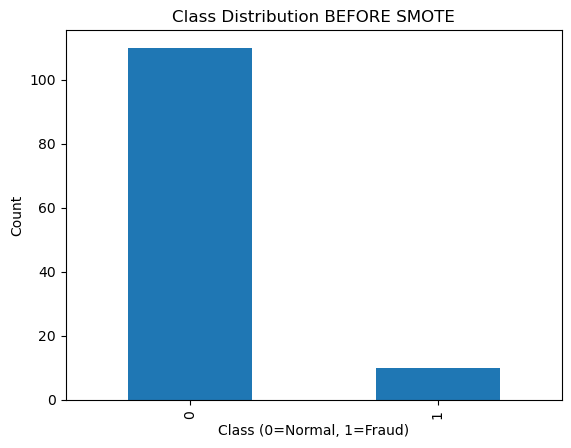

In [47]:
plt.figure()
df["Fraud"].value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

In [48]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
from sklearn.ensemble import RandomForestClassifier


In [51]:

model_before = RandomForestClassifier(n_estimators=100, random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

In [52]:
print("\n--- Before SMOTE ---")
print(classification_report(y_test, y_pred_before))


--- Before SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jayas\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [53]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [54]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64


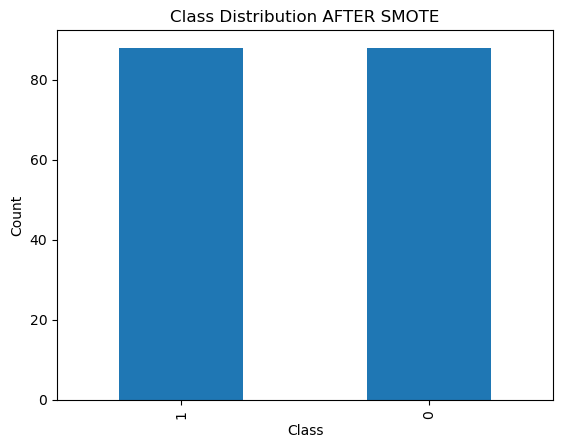

In [55]:
plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [56]:
model_after = RandomForestClassifier(n_estimators=100, random_state=42)
model_after.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [57]:
y_pred_after = model_after.predict(X_test)

print("\n--- After SMOTE ---")
print(classification_report(y_test, y_pred_after))


--- After SMOTE ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



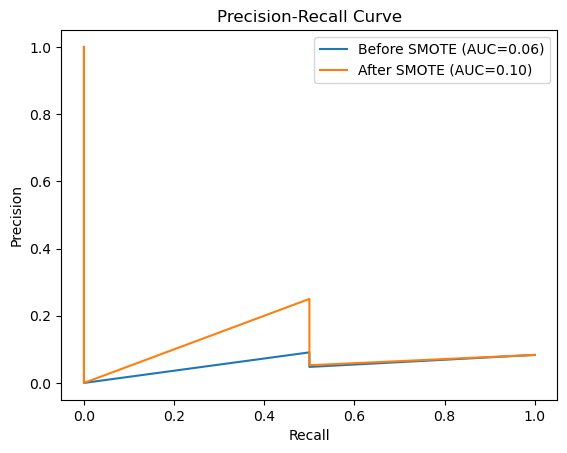

In [58]:

y_prob_before = model_before.predict_proba(X_test)[:, 1]
y_prob_after = model_after.predict_proba(X_test)[:, 1]

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(recall_b, precision_b)
pr_auc_after = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_a, precision_a, label=f"After SMOTE (AUC={pr_auc_after:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()